# Abhishek Kothari
# Assignemnt no 6

### Problem 1

In [3]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error
from math import sqrt
import zipfile
import os

In [5]:
zip_path = 'ml-100k.zip'
extract_path = 'ml-100k'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [7]:
train_file = os.path.join(extract_path, 'ml-100k', 'u1.base')
test_file = os.path.join(extract_path, 'ml-100k', 'u1.test')

column_names = ['user_id', 'item_id', 'rating', 'timestamp']
train_df = pd.read_csv(train_file, sep='\t', names=column_names, usecols=['user_id', 'item_id', 'rating'])
test_df = pd.read_csv(test_file, sep='\t', names=column_names, usecols=['user_id', 'item_id', 'rating'])


In [9]:
n_users = train_df['user_id'].nunique()
n_items = train_df['item_id'].nunique()

user_item_matrix = train_df.pivot(index='user_id', columns='item_id', values='rating').fillna(0)

In [11]:
user_similarity = cosine_similarity(user_item_matrix)
np.fill_diagonal(user_similarity, 0)  # don't consider self-similarity
user_similarity_df = pd.DataFrame(user_similarity, index=user_item_matrix.index, columns=user_item_matrix.index)


In [20]:
user_similarity_df.head()

user_id,1,2,3,4,5,6,7,8,9,10,...,934,935,936,937,938,939,940,941,942,943
user_id,,,,,,,,,,,,,,,,,,,,,
1,0.000000,0.097021,0.052469,0.021162,0.193545,0.290114,0.200438,0.097786,0.060791,0.200926,...,0.252187,0.090728,0.216186,0.139478,0.156937,0.095265,0.222958,0.158151,0.133090,0.252778
2,0.097021,0.000000,0.051348,0.084426,0.015516,0.187717,0.074479,0.023262,0.108167,0.078176,...,0.083045,0.298811,0.308608,0.403810,0.282896,0.213233,0.189257,0.132806,0.126597,0.101784
3,0.052469,0.051348,0.000000,0.145660,0.037180,0.084526,0.015718,0.086400,0.000000,0.030909,...,0.041330,0.036956,0.135750,0.063940,0.102082,0.034064,0.133720,0.083537,0.081230,0.019676
4,0.021162,0.084426,0.145660,0.000000,0.017291,0.000000,0.037566,0.046087,0.000000,0.023232,...,0.014238,0.047742,0.127305,0.118947,0.089016,0.039116,0.120521,0.135669,0.125925,0.035586
5,0.193545,0.015516,0.037180,0.017291,0.000000,0.158552,0.170890,0.157488,0.053846,0.089508,...,0.284295,0.074215,0.086345,0.063759,0.126358,0.068145,0.198118,0.142141,0.150000,0.239803


In [13]:
def predict_rating(user_id, item_id, k=5):
    if item_id not in user_item_matrix.columns:
        return train_df['rating'].mean()
    
    # Users who rated the item
    users_who_rated = user_item_matrix[user_item_matrix[item_id] > 0].index
    
    # Similarity scores
    sim_scores = user_similarity_df.loc[user_id, users_who_rated]
    
    # Get top-K similar users
    top_k_users = sim_scores.sort_values(ascending=False)[:k]
    
    # Ratings from top-K users
    top_k_ratings = user_item_matrix.loc[top_k_users.index, item_id]
    
    # Weighted average
    if top_k_ratings.sum() == 0 or top_k_users.sum() == 0:
        return train_df['rating'].mean()
    
    prediction = np.dot(top_k_ratings, top_k_users) / top_k_users.sum()
    return prediction

In [15]:
test_predictions = []
test_truth = []

for _, row in test_df.iterrows():
    pred = predict_rating(row['user_id'], row['item_id'], k=5)
    test_predictions.append(pred)
    test_truth.append(row['rating'])

In [17]:
rmse = sqrt(mean_squared_error(test_truth, test_predictions))
print(f"RMSE on test set: {rmse:.4f}")

RMSE on test set: 1.0690


### Question 3A

In [25]:
!pip install igraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 11.8 MB/s eta 0:00:00a 0:00:01


In [31]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.community import girvan_newman
from itertools import islice

In [43]:
# Load edge list (3K sampled)
edges_path = "edges_sampled_15K.csv"
edges = pd.read_csv(edges_path, header=None, names=["source", "target"])


In [45]:
# Create the graph
G = nx.Graph()
G.add_edges_from(edges.values)


In [47]:
# Apply Girvan-Newman Algorithm
def run_girvan_newman(graph, num_communities=5):
    comp = girvan_newman(graph)
    limited = next(islice(comp, num_communities - 1, None))
    return [list(c) for c in limited]

communities = run_girvan_newman(G, num_communities=5)

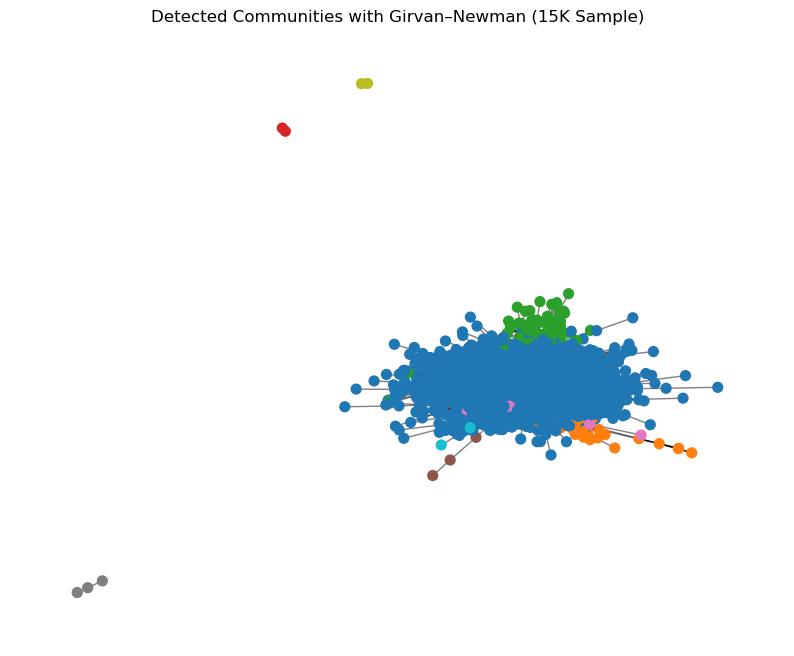

In [48]:
# Visualize Communities
def draw_communities(graph, communities):
    color_map = {}
    for i, community in enumerate(communities):
        for node in community:
            color_map[node] = i
    node_colors = [color_map.get(node, 0) for node in graph.nodes()]
    
    pos = nx.spring_layout(graph, seed=42)
    plt.figure(figsize=(10, 8))
    nx.draw_networkx_nodes(graph, pos, node_color=node_colors, cmap=plt.cm.tab10, node_size=50)
    nx.draw_networkx_edges(graph, pos, alpha=0.5)
    plt.title("Detected Communities with Girvan–Newman (15K Sample)")
    plt.axis("off")
    plt.show()

draw_communities(G, communities)

In [49]:
# Now lets evaluate our findings
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

In [50]:
# Load community ground truth
membership_df = pd.read_csv("community_membership_15K.csv", header=None)
membership_df.columns = ['node', 'community']


In [51]:
# Map node -> ground-truth community
ground_truth = membership_df.set_index('node')['community'].to_dict()

In [52]:
# Convert detected communities into labels for evaluation
def convert_communities_to_labels(graph, communities):
    node_to_community = {}
    for i, community in enumerate(communities):
        for node in community:
            node_to_community[node] = i
    valid_nodes = list(set(graph.nodes()).intersection(set(ground_truth.keys())))
    detected_labels = [node_to_community[n] for n in valid_nodes]
    true_labels = [ground_truth[n] for n in valid_nodes]
    return true_labels, detected_labels

# Assuming `G` is your graph and `communities` is the list of detected communities
true_labels, detected_labels = convert_communities_to_labels(G, communities)

In [53]:
# Compute evaluation metrics
nmi = normalized_mutual_info_score(true_labels, detected_labels)
ari = adjusted_rand_score(true_labels, detected_labels)

print("Normalized Mutual Information (NMI):", nmi)
print("Adjusted Rand Index (ARI):", ari)

Normalized Mutual Information (NMI): 0.05117975702443277
Adjusted Rand Index (ARI): 0.044583196681295734


### Question 3B

In [56]:
import numpy as np
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import eigsh
import matplotlib.pyplot as plt

In [66]:
def load_sparse_adj_matrix(filepath):
    """Loads the sparse adjacency matrix from a file."""
    data = np.genfromtxt(filepath, delimiter=',', dtype=int)
    nodes = np.unique(data[:, :2])
    node_to_idx = {node: idx for idx, node in enumerate(nodes)}
    size = len(nodes)
    A = np.zeros((size, size))
    for u, v, w in data:
        i, j = node_to_idx[u], node_to_idx[v]
        A[i, j] = w
        A[j, i] = w  # Undirected graph
    return A, node_to_idx

def compute_modularity_matrix(A):
    k = np.sum(A, axis=1)
    m = np.sum(k) / 2
    B = A - np.outer(k, k) / (2 * m)
    return B, k, m

In [68]:
def spectral_partitioning(B):
    eigvals, eigvecs = np.linalg.eigh(B)
    v1 = eigvecs[:, -1]  # Principal eigenvector
    s = np.where(v1 >= 0, 1, -1)  # Split vector
    return s

def compute_modularity(A, s, k, m):
    s = s.reshape(-1, 1)
    Q = (s.T @ (A - np.outer(k, k) / (2 * m)) @ s) / (4 * m)
    return Q[0, 0]

def modularity_split(filepath):
    A, node_to_idx = load_sparse_adj_matrix(filepath)
    B, k, m = compute_modularity_matrix(A)
    s = spectral_partitioning(B)
    Q = compute_modularity(A, s, k, m)

    idx_to_node = {i: n for n, i in node_to_idx.items()}
    community_1 = [idx_to_node[i] for i in range(len(s)) if s[i] == 1]
    community_2 = [idx_to_node[i] for i in range(len(s)) if s[i] == -1]

    return s, Q, community_1, community_2, A, node_to_idx


In [70]:
# Run the full pipeline
filepath = "sparse_adj.txt"
s, Q, comm1, comm2, A, node_to_idx = modularity_split(filepath)

print(f"Modularity Score: {Q:.4f}")
print("Community 1:", comm1)
print("Community 2:", comm2)

Modularity Score: 0.4382
Community 1: [321, 322, 323, 324, 325, 326, 327, 328, 329, 330, 331, 332, 333, 334, 335, 336, 337, 338, 339, 340, 341, 342, 343, 344, 345, 346, 347, 348, 349, 350, 351, 352, 353, 354, 355, 356, 357, 358, 359, 360, 361, 362, 363, 364, 365, 366, 367, 368, 369, 370, 371, 372, 373, 374, 375, 376, 377, 378, 379, 380, 381, 382, 383, 384, 385, 386, 387, 388, 389, 390, 391, 392, 393, 394, 395, 396, 397, 398, 399, 400, 401, 402, 403, 404, 405, 406, 407, 408, 409, 410, 411, 412, 413, 414, 415, 416, 417, 418, 419, 420, 421, 422, 423, 424, 425, 426, 427, 428, 429, 430, 431, 432, 433, 434, 435, 436, 437, 438, 439, 440, 441, 442, 443, 444, 445, 446, 447, 448, 449, 450, 451, 452, 453, 454, 455, 456, 457, 458, 459, 460, 461, 462, 463, 464, 465, 466, 467, 468, 469, 470, 471, 472, 473, 474, 475, 476, 477, 478, 479, 480, 481, 482, 483, 484, 485, 486, 487, 488, 489, 490, 491, 492, 493, 494, 495, 496, 497, 498, 499, 500, 501, 502, 503, 504, 505, 506, 507, 508, 509, 510, 511, 512, 5

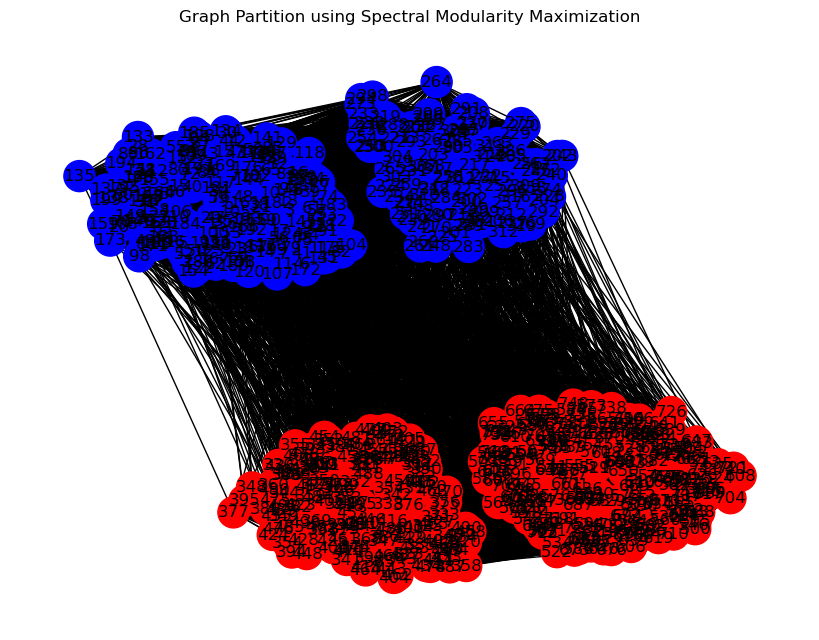

In [72]:
# Optional: Visualize the partitioned graph
def visualize_partition(A, s):
    G = nx.from_numpy_array(A)
    pos = nx.spring_layout(G, seed=42)
    colors = ['red' if si == 1 else 'blue' for si in s]
    plt.figure(figsize=(8, 6))
    nx.draw(G, pos, node_color=colors, with_labels=True, node_size=500)
    plt.title("Graph Partition using Spectral Modularity Maximization")
    plt.show()

visualize_partition(A, s)

### Question 4

In [17]:
import ast
import numpy as np
from collections import defaultdict
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
from nltk.tokenize import word_tokenize
from sklearn.metrics import f1_score

In [19]:
def load_knowledge_graph(filepath):
    graph = defaultdict(list)
    with open(filepath, 'r') as f:
        for line in f:
            src, rel, tgt = ast.literal_eval(line.strip())
            graph[src].append((rel, tgt))
    return graph


def load_questions(filepath):
    questions = []
    with open(filepath, 'r') as f:
        for line in f:
            parsed = ast.literal_eval(line.strip())
            qid, text, start, _, _, answers = parsed
            answers = set([ans['AnswerArgument'] for ans in answers])
            questions.append({'id': qid, 'text': text, 'start': start, 'answers': answers})
    return questions


def load_word2vec_model(path):
    return Word2Vec.load(path)  # You can use KeyedVectors if saved that way

In [21]:
def get_rel_score(rel, question, model):
    rel = 'ns:' + rel if not rel.startswith('ns:') else rel
    if rel not in model.wv:
        return 0.0
    q_tokens = word_tokenize(question.lower())
    q_vecs = [model.wv[w] for w in q_tokens if w in model.wv]
    if not q_vecs:
        return 0.0
    sim = cosine_similarity(np.mean(q_vecs, axis=0).reshape(1, -1), model.wv[rel].reshape(1, -1))
    return sim[0][0]


In [23]:
def answer_question(question, graph, model, threshold=0.3):
    start = question['start']
    q_text = question['text']
    predictions = set()
    if start not in graph:
        return predictions

    for rel, neighbor in graph[start]:
        score = get_rel_score(rel, q_text, model)
        if score > threshold:
            predictions.add(neighbor)

    return predictions


def compute_f1(true_answers, predicted_answers):
    if not predicted_answers:
        return 0.0
    y_true = [1 if a in true_answers else 0 for a in predicted_answers]
    y_pred = [1] * len(predicted_answers)
    return f1_score(y_true, y_pred)

In [25]:
def run_qa_pipeline(kg_path, questions_path, w2v_path):
    print("Loading data...")
    graph = load_knowledge_graph(kg_path)
    questions = load_questions(questions_path)
    model = load_word2vec_model(w2v_path)

    all_f1 = []
    for q in questions:
        pred = answer_question(q, graph, model)
        f1 = compute_f1(q['answers'], pred)
        print(f"Q{q['id']} | F1: {f1:.4f} | Predicted: {list(pred)} | Ground Truth: {list(q['answers'])}")
        all_f1.append(f1)

    avg_f1 = np.mean(all_f1)
    print(f"\n Average F1 Score across questions: {avg_f1:.4f}")

In [27]:
run_qa_pipeline(
    kg_path='knowledge_graph.txt',
    questions_path='questions.txt',
    w2v_path='word2vec_train_dev.dat.txt'  
)

Loading data...
Q1 | F1: 0.3333 | Predicted: ['m.03q1lvh', 'm.042g7t', 'm.04g4s8k', 'm.01_6pxw', 'm.09nqf', 'm.06yxd', 'm.0c9rw5', 'm.03v0t', 'm.04g4s8q', 'm.02jw0z', 'm.01_d4', 'm.03q1lvq', 'm.03q1lw4', 'm.06_7k', 'm.04g4s90', 'm.0fv_t', 'm.07b_l', 'm.02lcrv', 'm.0gs227r', 'm.01d9r3', 'm.0_hhjkj', 'm.09sh942', 'm.0bx8pn', 'm.02z431v', 'm.0w7m2x9', 'm.01ky66', 'm.03q1lwl', 'm.0vzm', 'm.02hczc', 'm.03q1lvy', 'm.01_6v6w', 'm.059g4', 'm.0b28z', 'm.01_77x6', 'm.02fqwt', 'm.027hqc_', 'm.04g4s8w', 'm.0mmyl', 'm.0j729', 'm.027wj2_', 'm.02lcqs', 'm.02lctm', 'm.027wjl3', 'm.01l1jx', 'm.02hcv8'] | Ground Truth: ['m.042g7t', 'm.02lcrv', 'm.02hczc', 'm.027wj2_', 'm.02lcqs', 'm.02lctm', 'm.027wjl3', 'm.02fqwt', 'm.02hcv8']
Q2 | F1: 0.0000 | Predicted: ['m.03q1lvh', 'm.042g7t', 'm.04g4s8k', 'm.01_6pxw', 'm.09nqf', 'm.06yxd', 'm.0c9rw5', 'm.03v0t', 'm.04g4s8q', 'm.02jw0z', 'm.01_d4', 'm.03q1lvq', 'm.03q1lw4', 'm.06_7k', 'm.04g4s90', 'm.0fv_t', 'm.07b_l', 'm.02lcrv', 'm.0gs227r', 'm.01d9r3', 'm.0_hhjk